In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Stage 1: Exploring The Folder Structure

In [ ]:
# I am exploring my folder structure (tree structure)
import os

#Going through everything in my uploaded dataset
input_path = "/kaggle/input/datasets/prospi/dhs-anc-data"

for root, dirs, files in os.walk(input_path):
    #I will skip hidden folders here
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace(input_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        filepath = os.path.join(root, file)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  {indent}{file}  ({size_mb:.1f} MB)")

# Stage 2: Install Libraries and Preprocess

In [ ]:
# Install pyreadstat
import subprocess
subprocess.run(["pip", "install", "pyreadstat", "-q"])
print ("Done")

In [ ]:
# Here I set the exact file paths to know where to read from
import os

BASE = "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw"

NIGERIA_IR = os.path.join(
    BASE,
    "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGIR8BDT/NGIR8BFL.dta")

KENYA_IR = os.path.join(
    BASE,
    "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw/kenya_2022/KE_2022_DHS_02122026_161_239942/KEIR8CDT/KEIR8CFL.DTA")

NIGERIA_GC = os.path.join(
    BASE,
    "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGGC8AFL/NGGC8AFL.csv")

KENYA_GC = os.path.join(
    BASE,
    "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw/kenya_2022/KE_2022_DHS_02122026_161_239942/KEGC8AFL/KEGC8AFL.csv")

# Confirm if each path resolves
for label, path in [("Nigeria IR", NIGERIA_IR), ("Kenya IR", KENYA_IR), ("Nigeria GC", NIGERIA_GC), ("Kenya GC", KENYA_GC)]:
    exists = os.path.exists(path)
    size = f"{os.path.getsize(path)/1e6:1f} MB" if exists else "NOT FOUND"
    print(f"{label:12s} {exists} {size} {path}")

In [ ]:
# Now let's check the column names without loading the full file

import pyreadstat
import warnings
warnings.filterwarnings("ignore")

def peek_columns(filepath):
    _, meta = pyreadstat.read_dta(filepath, row_limit=1)
    return [c.lower() for c in meta.column_names]

ng_cols = peek_columns(NIGERIA_IR)
ke_cols = peek_columns(KENYA_IR)

print(f"Nigeria IR columns: {len(ng_cols)}")
print(f"Kenya IR columns:   {len(ke_cols)}")

# Check every variable the chosen methodology requires
REQUIRED = [
    "m14",    # ANC visits — the outcome
    "v012",   # age
    "v106",   # education
    "v190",   # wealth quintile
    "v025",   # urban/rural
    "v024",   # region ADM1
    "v001",   # cluster ID
    "v005",   # sample weight
    "v201",   # total children
    "v218",   # living children
    "v467b",  # barrier: permission
    "v467c",  # barrier: money
    "v467d",  # barrier: distance
    "v467f",  # barrier: alone
    "v501",   # marital status
    "v730",   # partner education (often useful)
    "v102",   # region of residence alternative
    "v113",   # source of drinking water
    "v116",   # type of toilet facility
    "v161",   # type of cooking fuel
]

print("\n{:<10} {:>10} {:>10} {}".format("Variable", "Nigeria", "Kenya", "Status"))
print("-" * 45)
for var in REQUIRED:
    in_ng = var in ng_cols
    in_ke = var in ke_cols
    if in_ng and in_ke:
        status = "OK"
    elif in_ng and not in_ke:
        status = "Nigeria missing"
    else:
        status = "BOTH missing"
    print(f"{var:<10} {str(in_ng):>10} {status}")

In [ ]:
# Checked again for the type and number of columns
print(type(ng_cols))
print(type(ke_cols))

print(len(ng_cols))
print(len(ke_cols))

In [ ]:
# Printed out first 20 column names under Nigeria
print(ng_cols[:20])

In [ ]:
find_anc_variable(ng_cols, "Nigeria")

In [ ]:
KEEP_VARS = [
    "m14_1",
    "v012", "v106", "v190", "v025", "v024",
    "v001", "v005", "v201", "v218",
    "v467b", "v467c", "v467d", "v467f",
    "v501", "v730", "v113", "v116", "v161",
]

def load_ir(filepath, country_label, keep_vars, all_cols):
    load = [v for v in keep_vars if v in all_cols]
    skip = [v for v in keep_vars if v not in all_cols]
    if skip:
        print(f"[{country_label}] Skipping (not in file): {skip}")
    print(f"[{country_label}] Loading {len(load)} columns ...")
    df, _ = pyreadstat.read_dta(filepath, usecols=load, encoding="latin1")
    df.columns = df.columns.str.lower()
    df["country"] = country_label
    print(f"[{country_label}] Loaded {len(df):,} rows")
    return df

ng_raw = load_ir(NIGERIA_IR, "nigeria", KEEP_VARS, ng_cols)
ke_raw = load_ir(KENYA_IR,   "kenya",   KEEP_VARS, ke_cols)

In [ ]:
# m14 was not found in the columns
# Knowing that the IR file has one row per woman with multiple births
# I will use m14_1 as the most recent birth instead of m14
# Update KEEP_VARS to replace m14 with m14_1

KEEP_VARS = [
    "m14_1", # ANC visits for most recent birth, replaces m14
    "v012", "v106", "v190", "v025", "v024",
    "v001", "v005", "v201", "v218",
    "v467b", "v467c", "v467d", "v467f",
    "v501", "v730", "v113", "v116", "v161",
]

# Verify that both files have it
print("m14_1 in Nigeria:", "m14_1" in ng_cols)
print("m14_1 in Kenya:", "m14_1" in ke_cols)




In [ ]:
def build_outcome(df, country_label, threshold=4):
    df = df.copy()
    df = df.rename(columns={"m14_1": "m14"})
    df["m14"] = pd.to_numeric(df["m14"], errors="coerce")
    df.loc[df["m14"] >= 98, "m14"] = np.nan
    before = len(df)
    df = df.dropna(subset=["m14"]).copy()
    df["anc_adequate"] = (df["m14"] >= threshold).astype(int)
    rate = df["anc_adequate"].mean() * 100
    print(f"[{country_label}] Rows: {len(df):,} | Dropped: {before-len(df):,} | ANC adequate: {rate:.1f}%")
    return df

ng = build_outcome(ng_raw, "nigeria")
ke = build_outcome(ke_raw, "kenya")

In [ ]:
# The number of rows dropped were almost double those that remained
# Dropped rows are women who either had no recent birth or were not asked the question
# Check the retained rows make sense demographically
# Nigeria's poorest quintile (3,648) is nearly double the richest (2,050).

for df, label in [(ng, "Nigeria"), (ke, "Kenya")]:
    print(f"\n{label}")
    print(f"  Rows retained        : {len(df):,}")
    print(f"  ANC adequate rate    : {df['anc_adequate'].mean()*100:.1f}%")
    print(f"  Age range            : {df['v012'].min():.0f} – {df['v012'].max():.0f}")
    print(f"  Wealth distribution  :\n{df['v190'].value_counts().sort_index()}")
    print(f"  Urban share          : {(df['v025']==1).mean()*100:.1f}%")

In [ ]:
# Clean DHS sentinel codes
# Protected columns are not touched
# Replace missing values with NaN
# Cleaning both datasets
# Create an urban indicator

def clean_dhs(df, country_label):
    df = df.copy() # Prevents modifying the original dataset
    protected = {"m14", "anc_adequate", "country", "v001", "v005", "v024", "v025", "v190", "v106"}
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
               if c not in protected] # Clean all variables except in protected columns
    for col in num_cols:
        col_max = df[col].max()
        if col_max in [8,9]: df.loc[df[col] >= 8, col] = np.nan
        elif col_max in [98,99]: df.loc[df[col] >= 98, col] = np.nan
        elif col_max in [998, 999]: df.loc[df[col] >= 998, col] = np.nan
    df["sample_weight"] = df["v005"] / 1_000_000 # Converts weights back to real weights
    df = df.drop(columns=["v005"]) # Replace original weight with new sample_weight
    df["urban"] = (df["v025"] == 1).astype(int)
    print(f"[{country_label}] Cleaning complete")
    return df
ng = clean_dhs(ng, "nigeria")
ke = clean_dhs(ke, "kenya")

In [ ]:
# Finding out what would be dropped
# Preview what will be dropped before running align_and_combine
ng_only = set(ng.columns) - set(ke.columns)
ke_only = set(ke.columns) - set(ng.columns)
common  = set(ng.columns) & set(ke.columns)

print(f"Shared columns (kept)        : {len(common)}")
print(f"Nigeria-only (will be dropped): {sorted(ng_only)}")
print(f"Kenya-only (will be dropped)  : {sorted(ke_only)}")

In [ ]:
# Align and combine columns
# Keeps only shared columns which is essential for horizontal federated learning

def align_and_combine(ng, ke):
    common = sorted(set(ng.columns) & set(ke.columns)) # Keeping common values in each dataset for fair comparisons
    ng_only = set(ng.columns) - set(ke.columns)
    ke_only = set(ke.columns) - set(ng.columns)
    if ng_only: print(f"Nigeria-only dropped: {sorted(ng_only)}")
    if ke_only: print(f"Kenya-only dropped: {sorted(ke_only)}")
    df = pd.concat([ng[common], ke[common]], ignore_index=True)
    print(f"Combined shape : {df.shape}")
    print(f"Countries : {df['country'].value_counts().to_dict()}")
    return df

combined = align_and_combine(ng, ke)

In [ ]:
# Handling missing values
# Data preprocessing pipeline


from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

DROP_THRESH  = 0.30 # Drop column if missing above 30%
MEDIAN_THRESH = 0.05 # 0-5% fill with median

def handle_missing(df):
    df = df.copy()
    meta_cols = {"anc_adequate", "m14", "country", "v001", "sample_weight",
                 "v024", "v025", "urban", "v190", "v106"}
    feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                 if c not in meta_cols] # Only numberical values are cleaned
    rates = df[feat_cols].isnull().mean().sort_values(ascending=False) # Calculates % of missing values per column

    # Report columns that have missing values
    has_missing = rates[rates > 0]
    print("Missingness:" if len(has_missing) else "No missing values.")
    if len(has_missing):
        print(has_missing.mul(100).round(1).to_string())

    # Tier 0: drop >30%
    drop_cols = rates[rates > DROP_THRESH].index.tolist()
    if drop_cols:
        print(f"\nDropping (>30% missing): {drop_cols}")
        df = df.drop(columns=drop_cols)
        rates = rates.drop(drop_cols)
        feat_cols = [c for c in feat_cols if c not in drop_cols]

    # Tier 1: median impute <5%
    low_cols = rates[rates <= MEDIAN_THRESH].index.tolist()
    if low_cols:
        df[low_cols] = df[low_cols].fillna(df[low_cols].median())
        print(f"Median-imputed: {len(low_cols)} columns")

    # Tier 2: iterative impute 5–30%
    mid_cols = rates[(rates > MEDIAN_THRESH) & (rates <= DROP_THRESH)].index.tolist()
    if mid_cols:
        print(f"Iterative-imputing: {mid_cols}")
        imp = IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=10, random_state=42),
            max_iter=5, random_state=42
        )
        df[mid_cols] = imp.fit_transform(df[mid_cols]) # Replaces missing values with model predictions
        print("Done")
    return df

combined = handle_missing(combined) # Applies the cleaning to the merged dataset

In [ ]:
# Verify previous changes and save

import os

print("=" * 45)
print(f"Shape            : {combined.shape}") # Shows dataset size

print("\nANC rate by country:") # ANC average by country
print(combined.groupby("country")["anc_adequate"]
      .agg(N="count", ANC_pct=lambda x: round(x.mean()*100, 1)))

print("\nANC rate by wealth quintile:") # Inequality in healthcare access
print(combined.groupby("v190")["anc_adequate"].mean().mul(100).round(1))

print("\nANC rate by urban/rural (1=urban 0=rural):") # ANC by urban vs rural
print(combined.groupby("urban")["anc_adequate"].mean().mul(100).round(1))

print("\nRemaining missing:") # Keeps columns that still have missing values if any
mv = combined.isnull().sum()
mv = mv[mv > 0]
print(mv if len(mv) else "None")

os.makedirs("/kaggle/working/processed", exist_ok=True) # Creates folder to save file as parquet
save_path = "/kaggle/working/processed/combined_clean.parquet"
combined.to_parquet(save_path, index=False) 
print(f"\nSaved : {save_path}")
print(f"Size  : {os.path.getsize(save_path)/1e6:.1f} MB") # Confirms the saved file

In [ ]:
# There were some 4,941 missing values in barrier variables and 2,669 in v730
# These values appeared to have low missingness but were actually still dirty

# Force clean remaining missing values
barrier_cols = ["v467b", "v467c", "v467d", "v467f"]
partner_col  = ["v730"]

# Barrier variables: missing means the question was not asked
# (woman had no barrier or was not in the reference group)
# Treat as 0 = no barrier reported
combined[barrier_cols] = combined[barrier_cols].fillna(0)

# Partner education: fill with median
combined["v730"] = combined["v730"].fillna(combined["v730"].median())

# Confirm
mv = combined.isnull().sum()
mv = mv[mv > 0]
print("Remaining missing after fix:")
print(mv if len(mv) else "None — all clean")
print(f"\nShape: {combined.shape}")

In [ ]:
# Now to resave the file

combined.to_parquet("/kaggle/working/processed/combined_clean.parquet", index=False)
print("Saved cleanly")

# Stage 3: Client Paritioning

In [ ]:
# Load saved data 
import pandas as pd
import numpy as np
import os

np.random.seed(42) # Ensures reproducibility

combined = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-processed/dhs-anc-processed.parquet")
print(f"Loaded: {combined.shape}")
print(combined["country"].value_counts().to_dict())


In [ ]:
# Begin Client Partitioning
# Split into 4 clients based on country + urban stratum
client_1 = combined[(combined["country"] == "nigeria") & (combined["urban"] == 1)].copy()
client_2 = combined[(combined["country"] == "nigeria") & (combined["urban"] == 0)].copy()
client_3 = combined[(combined["country"] == "kenya")   & (combined["urban"] == 1)].copy()
client_4 = combined[(combined["country"] == "kenya")   & (combined["urban"] == 0)].copy()

clients = {
    "nigeria_urban" : client_1,
    "nigeria_rural" : client_2,
    "kenya_urban"   : client_3,
    "kenya_rural"   : client_4,
} # Storing the items in a python dictionary

print("Client summary:")
print(f"{'Client':<20} {'N':>6} {'ANC%':>8} {'Wealth_mode':>12}")
print("-" * 50)
for name, df in clients.items():
    n    = len(df)
    anc  = df["anc_adequate"].mean() * 100
    wlth = df["v190"].mode()[0]
    print(f"{name:<20} {n:>6} {anc:>7.1f}% {wlth:>12}")

In [ ]:
# Apply Dirichlet label skew (non-IID)
#  Making ANC distributions realistically heterogeneous rather than artificially balanced
# Re-did because the Ditichlet function resmapled too aggressively
# Removed Dirichlet sampling altogether because it overrides geographical signals within the data
# The geographic split already creates natural non-IID conditions.


# The geographic split (country x urban/rural) already creates
# natural non-IID conditions. No Dirichlet resampling needed.
# This is valid and consistent with your methodology Section 3.3.1A.

clients_skewed = {}
for name, df in clients.items():
    clients_skewed[name] = df.reset_index(drop=True)

print("Client summary (natural geographic split):")
print(f"{'Client':<20} {'N':>6} {'ANC%':>8}")
print("-" * 38)
for name, df in clients_skewed.items():
    print(f"{name:<20} {len(df):>6} {df['anc_adequate'].mean()*100:>7.1f}%")

In [ ]:
# Converting the skewed client dataset into train/validation/test split

from sklearn.model_selection import train_test_split

def split_client(df, train_size=0.70, val_size=0.15, seed=42):
    """
    Split client data into 70% train, 15% validation, 15% test.
    Stratified on outcome to preserve class balance within each split.
    """
    # First split: train vs temp (val + test)
    train, temp = train_test_split(
        df,
        test_size=(1 - train_size),
        stratify=df["anc_adequate"],
        random_state=seed
    )

    # Second split: val vs test from temp
    relative_val = val_size / (1 - train_size)
    val, test = train_test_split(
        temp,
        test_size=(1 - relative_val),
        stratify=temp["anc_adequate"],
        random_state=seed
    )

    return train.reset_index(drop=True), \
           val.reset_index(drop=True),   \
           test.reset_index(drop=True)

client_splits = {}
print(f"{'Client':<20} {'Train':>7} {'Val':>6} {'Test':>6}")
print("-" * 42)
for name, df in clients_skewed.items():
    train, val, test = split_client(df)
    client_splits[name] = {
        "train" : train,
        "val"   : val,
        "test"  : test,
    }
    print(f"{name:<20} {len(train):>7} {len(val):>6} {len(test):>6}")

In [ ]:
# Global test set: 20% of full combined data, unseen by all models
# This is the common evaluation set for fair comparison across all variants
# The benchmark dataset will be evaluated against

global_train, global_test = train_test_split(
    combined,
    test_size=0.20,
    stratify=combined["anc_adequate"],
    random_state=42
)

print(f"Global train : {len(global_train):,}")
print(f"Global test  : {len(global_test):,}")
print(f"Global test ANC rate: {global_test['anc_adequate'].mean()*100:.1f}%")

In [ ]:
# Visualising the federated learning setup summary

import os
import matplotlib.pyplot as plt

# Plot ANC rates across clients to confirm genuine heterogeneity
names = list(client_splits.keys())
anc_rates = [client_splits[n]["train"]["anc_adequate"].mean()*100 for n in names]
sizes     = [len(client_splits[n]["train"]) for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ANC rates per client
axes[0].bar(names, anc_rates, color=["#2196F3","#1565C0","#4CAF50","#2E7D32"])
axes[0].axhline(combined["anc_adequate"].mean()*100,
                color="red", linestyle="--", label="Global mean")
axes[0].set_title("ANC Adequate Rate per Client (Train)")
axes[0].set_ylabel("ANC Adequate %")
axes[0].set_ylim(0, 100)
axes[0].legend()
for i, v in enumerate(anc_rates):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

# Dataset sizes per client
axes[1].bar(names, sizes, color=["#2196F3","#1565C0","#4CAF50","#2E7D32"])
axes[1].set_title("Training Set Size per Client")
axes[1].set_ylabel("Number of samples")
for i, v in enumerate(sizes):
    axes[1].text(i, v + 10, str(v), ha="center", fontsize=9)

plt.xticks(rotation=15)
plt.tight_layout()
os.makedirs("/kaggle/working/processed", exist_ok=True)
plt.savefig("/kaggle/working/processed/client_partition_summary.png", dpi=150)
plt.show()
print("Plot saved")

In [ ]:
# Saving all partitions to disk to avoid preprocessing repetition
import pickle

save_dir = "/kaggle/working/processed"
os.makedirs(save_dir, exist_ok=True)

# Save client splits
with open(f"{save_dir}/client_splits.pkl", "wb") as f:
    pickle.dump(client_splits, f)

# Save global sets
global_train.to_parquet(f"{save_dir}/global_train.parquet", index=False)
global_test.to_parquet(f"{save_dir}/global_test.parquet",  index=False)

# Confirm
print("Saved files:")
for fname in os.listdir(save_dir):
    fpath = os.path.join(save_dir, fname)
    print(f"  {fname:<40} {os.path.getsize(fpath)/1e6:.2f} MB")

# Stage 4: Centralised Baseline Models

In [ ]:
# Setting up the environment for training
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42) # Ensuring reproducibility

# Load global train and test sets
global_train = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-partitions/global_train.parquet")
global_test  = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-partitions/global_test.parquet")

# Load client splits
with open("/kaggle/input/datasets/prospi/dhs-anc-partitions/client_splits.pkl", "rb") as f:
    client_splits = pickle.load(f)

print(f"Global train : {global_train.shape}")
print(f"Global test  : {global_test.shape}")
print(f"Clients      : {list(client_splits.keys())}")

In [ ]:
# Prepare the dataset for machine learning
# Columns that are not features
NON_FEATURES = [
    "anc_adequate", "m14", "country", "v001",
    "sample_weight", "v024", "v025"
]

def get_X_y(df):
    feature_cols = [c for c in df.columns if c not in NON_FEATURES]
    X = df[feature_cols].copy()
    y = df["anc_adequate"].copy()
    return X, y

X_train, y_train = get_X_y(global_train)
X_test,  y_test  = get_X_y(global_test)

print(f"Features     : {X_train.shape[1]}")
print(f"Feature list : {list(X_train.columns)}")
print(f"Train rows   : {len(X_train)}")
print(f"Test rows    : {len(X_test)}")
print(f"Train ANC%   : {y_train.mean()*100:.1f}%")
print(f"Test ANC%    : {y_test.mean()*100:.1f}%")

In [ ]:
# Training and evaluating the Logistic Regression Model on the ANC dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             f1_score, classification_report)

lr = LogisticRegression( # Defining the model
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train, y_train)

# Evaluate
lr_pred  = lr.predict(X_test)
lr_prob  = lr.predict_proba(X_test)[:, 1]
lr_acc   = accuracy_score(y_test, lr_pred)
lr_auc   = roc_auc_score(y_test, lr_prob)
lr_f1    = f1_score(y_test, lr_pred)

print("Logistic Regression Results:")
print(f"  Accuracy : {lr_acc:.4f}")
print(f"  AUC      : {lr_auc:.4f}")
print(f"  F1       : {lr_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred))

In [ ]:
# Train and evaluates an XGBoost classification model on your ANC dataset
# Report its performance

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit( # Trains the model on training data
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Evaluate
xgb_pred = xgb.predict(X_test) # Class predictions 0-1
xgb_prob = xgb.predict_proba(X_test)[:, 1] # Probability predictions
xgb_acc  = accuracy_score(y_test, xgb_pred) # Evaluation metrics
xgb_auc  = roc_auc_score(y_test, xgb_prob) # How well the model differentiates negative, positive cases
xgb_f1   = f1_score(y_test, xgb_pred) # Balances precision and recall

print("XGBoost Results:")
print(f"  Accuracy : {xgb_acc:.4f}")
print(f"  AUC      : {xgb_auc:.4f}")
print(f"  F1       : {xgb_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred))

In [ ]:
# Comparing both Logistic Regression and XGBoost

print("=" * 45)
print(f"{'Model':<25} {'Accuracy':>9} {'AUC':>7} {'F1':>7}")
print("-" * 45)
print(f"{'Logistic Regression':<25} {lr_acc:>9.4f} {lr_auc:>7.4f} {lr_f1:>7.4f}")
print(f"{'XGBoost':<25} {xgb_acc:>9.4f} {xgb_auc:>7.4f} {xgb_f1:>7.4f}")
print("=" * 45)

In [ ]:
# SHAP explanations for XGBoost

import shap

print("Computing SHAP values for XGBoost...")
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Global feature importance — mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
 "feature" : X_test.columns,
 "mean_abs_shap" : np.abs(shap_values_xgb).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 10 features by SHAP importance (XGBoost centralised):")
print(shap_importance.head(10).to_string(index=False))

In [ ]:
# SHAP explanations for Logistic Regression

print("Computing SHAP values for Logistic Regression...")
explainer_lr = shap.LinearExplainer(lr, X_train) # Explains the model using training data as background
shap_values_lr = explainer_lr.shap_values(X_test)

shap_importance_lr = pd.DataFrame({
 "feature" : X_test.columns,
 "mean_abs_shap" : np.abs(shap_values_lr).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 10 features by SHAP importance (Logistic Regression centralised):")
print(shap_importance_lr.head(10).to_string(index=False))

In [ ]:
# SHAP summary plot

import matplotlib.pyplot as plt

os.makedirs("/kaggle/working/processed", exist_ok=True)

# XGBoost SHAP summary plot
shap.summary_plot(
    shap_values_xgb,
    X_test,
    max_display=10,
    show=False
)
plt.title("XGBoost Centralised — SHAP Feature Importance")
plt.tight_layout()
plt.savefig("/kaggle/working/processed/shap_xgb_centralised.png", dpi=150)
plt.show()
print("SHAP plot saved")

In [ ]:
# Save the both models and the SHAP values
# Saves the full machine learning pipeline

import pickle

save_dir = "/kaggle/working/processed"

# Save models
with open(f"{save_dir}/lr_model.pkl", "wb") as f:
    pickle.dump(lr, f)

with open(f"{save_dir}/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

# Save SHAP values and importance tables
with open(f"{save_dir}/shap_values_xgb.pkl", "wb") as f:
    pickle.dump(shap_values_xgb, f)

with open(f"{save_dir}/shap_values_lr.pkl", "wb") as f:
    pickle.dump(shap_values_lr, f)

shap_importance.to_parquet(f"{save_dir}/shap_importance_xgb.parquet", index=False)
shap_importance_lr.to_parquet(f"{save_dir}/shap_importance_lr.parquet", index=False)

# Save feature column list — needed for federated simulation
feature_cols = list(X_train.columns)
with open(f"{save_dir}/feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Saved files:")
for fname in os.listdir(save_dir):
    fpath = os.path.join(save_dir, fname)
    print(f"  {fname:<45} {os.path.getsize(fpath)/1e6:.2f} MB")

In [ ]:
# Display the image directly in the notebook
# Confirming the image was saved

from IPython.display import Image
Image("/kaggle/working/processed/shap_xgb_centralised.png")

# Step 5: Federated Learning Simulation

In [1]:
import pandas as pd 
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings("ignore") # Hiding unnecessary warning messages

np.random.seed(42)

# Load partitions
global_train = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-partitions/global_train.parquet")
global_test = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-partitions/global_test.parquet")

with open("/kaggle/input/datasets/prospi/dhs-anc-partitions/client_splits.pkl", "rb") as f:
    client_splits = pickle.load(f)

# Load feature columns
with open("/kaggle/input/datasets/prospi/dhs-anc-baselines/feature_cols.pkl", "rb") as f:
    client_splits = pickle.load(f)

# Load SHAP reference rankings
shap_ref_xgb = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-baselines/shap_importance_xgb.parquet")

print(f"Global train : {global_train.shape}")
print(f"Global test : {global_test.shape}")
print(f"Clients : {list(client_splits.keys())}")
print(f"Features : {len(feature_cols)}")
print(f"SHAP ref top3 : {shap_ref_xgb['feature'].head(3).tolist()}")

Global train : (19179, 22)
Global test : (4795, 22)


AttributeError: 'list' object has no attribute 'keys'

In [2]:
# I had an issue where the "client_splits.pkl" became a corrupted file
# Check what type it loaded as
print(type(client_splits))
print(client_splits[0] if isinstance(client_splits, list) else client_splits)

<class 'list'>
urban


In [3]:
# To fix the dictionary error, I checked the file paths
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath) / 1e6
        print(f"{size:>8.2f} MB  {filepath}")

    0.18 MB  /kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGMR8B/NGMR8B.dcf
    3.02 MB  /kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGMR8B/NGMR8B.frw
   14.81 MB  /kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGMR8B/NGMR8B.dat
    0.06 MB  /kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGMR8B/NGIR8B.docx
    3.02 MB  /kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGMR8B/NGMR8B.frq
    0.22 MB  /kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGMR8B/NGMR8B.map
   41.21 MB  /kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGKR8BDT/NGKR8BFL.dta
    0.26 MB  /kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02

In [4]:
# Updated the my data loading and preparation for training with correct file paths

import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ── Exact paths ───────────────────────────────────────────────────────────────
COMBINED     = "/kaggle/input/datasets/prospi/dhs-anc-processed/dhs-anc-processed.parquet"
GLOBAL_TRAIN = "/kaggle/input/datasets/prospi/dhs-anc-partitions/global_train.parquet"
GLOBAL_TEST  = "/kaggle/input/datasets/prospi/dhs-anc-partitions/global_test.parquet"
CLIENT_SPLITS= "/kaggle/input/datasets/prospi/dhs-anc-partitions/client_splits.pkl"
FEATURE_COLS = "/kaggle/input/datasets/prospi/dhs-anc-baselines/feature_cols.pkl"
SHAP_IMP_XGB = "/kaggle/input/datasets/prospi/dhs-anc-baselines/shap_importance_xgb.parquet"

# ── Load ──────────────────────────────────────────────────────────────────────
global_train = pd.read_parquet(GLOBAL_TRAIN)
global_test  = pd.read_parquet(GLOBAL_TEST)
combined     = pd.read_parquet(COMBINED)

with open(FEATURE_COLS, "rb") as f:
    feature_cols = pickle.load(f)

shap_ref_xgb = pd.read_parquet(SHAP_IMP_XGB)

print(f"Global train  : {global_train.shape}")
print(f"Global test   : {global_test.shape}")
print(f"Combined      : {combined.shape}")
print(f"Features      : {len(feature_cols)}")
print(f"SHAP ref top3 : {shap_ref_xgb['feature'].head(3).tolist()}")

Global train  : (19179, 22)
Global test   : (4795, 22)
Combined      : (23974, 22)
Features      : 15
SHAP ref top3 : ['v106', 'v190', 'v161']


In [5]:
# Rebuilt the "client_splits" dataset to fix the corrupted file
from sklearn.model_selection import train_test_split

# Rebuild client splits from combined data
clients = {
    "nigeria_urban": combined[(combined["country"]=="nigeria") & (combined["urban"]==1)].copy(),
    "nigeria_rural": combined[(combined["country"]=="nigeria") & (combined["urban"]==0)].copy(),
    "kenya_urban"  : combined[(combined["country"]=="kenya")   & (combined["urban"]==1)].copy(),
    "kenya_rural"  : combined[(combined["country"]=="kenya")   & (combined["urban"]==0)].copy(),
}

def split_client(df, seed=42):
    train, temp = train_test_split(df, test_size=0.30,
                                   stratify=df["anc_adequate"], random_state=seed)
    val, test   = train_test_split(temp, test_size=0.50,
                                   stratify=temp["anc_adequate"], random_state=seed)
    return {"train": train.reset_index(drop=True),
            "val":   val.reset_index(drop=True),
            "test":  test.reset_index(drop=True)}

client_splits = {name: split_client(df) for name, df in clients.items()}

print(f"{'Client':<20} {'Train':>7} {'Val':>6} {'Test':>6} {'ANC%':>8}")
print("-" * 52)
for name, splits in client_splits.items():
    anc = splits["train"]["anc_adequate"].mean() * 100
    print(f"  {name:<20} {len(splits['train']):>7} "
          f"{len(splits['val']):>6} {len(splits['test']):>6} {anc:>7.1f}%")

Client                 Train    Val   Test     ANC%
----------------------------------------------------
  nigeria_urban           3549    761    761    73.4%
  nigeria_rural           5966   1278   1279    41.6%
  kenya_urban             2512    538    539    69.9%
  kenya_rural             4753   1019   1019    58.4%


In [6]:
# Now to save the new "client_splits" dataset and upload it to private kaggle datasets
import pickle
import os

os.makedirs("/kaggle/working/processed", exist_ok=True)

# Save corrected client splits
with open("/kaggle/working/processed/client_splits.pkl", "wb") as f:
    pickle.dump(client_splits, f)

# Verify
with open("/kaggle/working/processed/client_splits.pkl", "rb") as f:
    test_load = pickle.load(f)

print(f"Type    : {type(test_load)}")
print(f"Clients : {list(test_load.keys())}")
print("Saved correctly — ready to overwrite dataset")

Type    : <class 'dict'>
Clients : ['nigeria_urban', 'nigeria_rural', 'kenya_urban', 'kenya_rural']
Saved correctly — ready to overwrite dataset


In [7]:
# I checked the data to confirm that it was fixed back to "dict" format instead of "list"
import pickle

# Load from the dataset to confirm it reflects the fix
with open("/kaggle/input/datasets/prospi/dhs-anc-partitions/client_splits.pkl", "rb") as f:
    verify = pickle.load(f)

# Check type
print(f"Type    : {type(verify)}")

# Check keys
print(f"Clients : {list(verify.keys())}")

# Check splits
print(f"\n{'Client':<20} {'Train':>7} {'Val':>6} {'Test':>6} {'ANC%':>8}")
print("-" * 52)
for name, splits in verify.items():
    anc = splits["train"]["anc_adequate"].mean() * 100
    print(f"  {name:<20} {len(splits['train']):>7} "
          f"{len(splits['val']):>6} {len(splits['test']):>6} {anc:>7.1f}%")

Type    : <class 'dict'>
Clients : ['nigeria_urban', 'nigeria_rural', 'kenya_urban', 'kenya_rural']

Client                 Train    Val   Test     ANC%
----------------------------------------------------
  nigeria_urban           3549    761    761    73.4%
  nigeria_rural           5966   1278   1279    41.6%
  kenya_urban             2512    538    539    69.9%
  kenya_rural             4753   1019   1019    58.4%


In [8]:
# Preparing the dhs dataset for training in federated learning using PyTorch
# First import deep learning tools
# Edited the code in the second iretation to take advantage of the GPU T4

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Check GPU availability (second iteration)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

NON_FEATURES = [
    "anc_adequate", "m14", "country", "v001",
    "sample_weight", "v024", "v025"
]

# Scale features using global train statistics
scaler = StandardScaler()
scaler.fit(global_train[feature_cols])

def scale_and_tensor(df, feature_cols, scaler):
    X = scaler.transform(df[feature_cols].values.astype(np.float32))
    y = df["anc_adequate"].values.astype(np.float32)
    return (torch.tensor(X, dtype=torch.float32).to(device),
            torch.tensor(y, dtype=torch.float32).to(device))

# Prepare global test tensors
X_test_tensor, y_test_tensor = scale_and_tensor(
    global_test, feature_cols, scaler
)

# Prepare client tensors
client_tensors = {}
for name, splits in client_splits.items():
    client_tensors[name] = {
        "train": scale_and_tensor(splits["train"], feature_cols, scaler),
        "val"  : scale_and_tensor(splits["val"],   feature_cols, scaler),
        "test" : scale_and_tensor(splits["test"],  feature_cols, scaler),
    }

print("Client tensor shapes:")
for name, tensors in client_tensors.items():
    X, y = tensors["train"]
    print(f"  {name:<20} X:{X.shape}  y:{y.shape}  device:{X.device}")

Using device: cuda
Client tensor shapes:
  nigeria_urban        X:torch.Size([3549, 15])  y:torch.Size([3549])  device:cuda:0
  nigeria_rural        X:torch.Size([5966, 15])  y:torch.Size([5966])  device:cuda:0
  kenya_urban          X:torch.Size([2512, 15])  y:torch.Size([2512])  device:cuda:0
  kenya_rural          X:torch.Size([4753, 15])  y:torch.Size([4753])  device:cuda:0


In [10]:
# Defining the nueral network model to be used
# Updated to use GPU
# Simple feedforward neural network for ANC utilisation prediction.
# Two hidden layers with dropout for regularisation.

class ANCModel(nn.Module):
    def __init__(self, input_dim):
        super(ANCModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze()

input_dim  = len(feature_cols)
test_model = ANCModel(input_dim).to(device)  # move model to GPU
print(f"Input dimension  : {input_dim}")
print(f"Model parameters : {sum(p.numel() for p in test_model.parameters()):,}")
print(f"Model device     : {next(test_model.parameters()).device}")

Input dimension  : 15
Model parameters : 3,137
Model device     : cuda:0


In [13]:
# Training the ML model locally on one device
# Updated to use GPU 
# Train model locally on one client for a fixed number of epochs.
# Returns updated model weights only — raw data never leaves client.

def local_train(model, X_train, y_train, epochs=5, lr=0.01, batch_size=64):
    model = model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    dataset   = TensorDataset(X_train, y_train)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
    return model.state_dict()

In [14]:
# To combine fedavg and coord_median model updates from multiple clients
def fedavg(client_weights, client_sizes):
    """
    Federated Averaging: weighted average of client model parameters.
    Weight proportional to client dataset size, capped at 40%.
    """
    total     = sum(client_sizes)
    raw_weights = [s / total for s in client_sizes]

    # Cap at 40% to prevent any single client dominating
    cap       = 0.40
    capped    = [min(w, cap) for w in raw_weights]
    cap_total = sum(capped)
    norm_weights = [w / cap_total for w in capped]

    # Weighted average of parameters
    avg_state = {}
    for key in client_weights[0].keys():
        avg_state[key] = sum(
            norm_weights[i] * client_weights[i][key]
            for i in range(len(client_weights))
        )
    return avg_state


def coord_median(client_weights):
    """
    Coordinate-wise median aggregation.
    Robust to Byzantine corrupted client updates.
    """
    median_state = {}
    for key in client_weights[0].keys():
        stacked       = torch.stack([cw[key] for cw in client_weights])
        median_state[key] = torch.median(stacked, dim=0).values
    return median_state

In [15]:
# Evaluating the trained ML model on a test dataset
# Evaluate model on test set. Returns accuracy, AUC, F1.
# Updated to use GPU

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        probs = model(X_test.to(device)).cpu().numpy()
    preds = (probs >= 0.5).astype(int)
    y_np  = y_test.cpu().numpy().astype(int)
    return {
        "accuracy": accuracy_score(y_np, preds),
        "auc"     : roc_auc_score(y_np, probs),
        "f1"      : f1_score(y_np, preds),
    }

In [20]:
# A full federated learning simulation
# Updated to use GPU
...
def run_federated(
    client_tensors,
    X_test, y_test,
    input_dim,
    aggregation       = "fedavg",
    num_rounds        = 50,
    local_epochs      = 5,
    failure_mode      = None,
    dropout_prob      = 0.30,
    byzantine_fraction= 0.20,
    byzantine_std     = 5.0,
    stale_prob        = 0.20,
    staleness_window  = 3,
    seed              = 42,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    client_names = list(client_tensors.keys())
    K            = len(client_names)

    # ── Initialise global model on GPU ───────────────────────────────────────
    global_model = ANCModel(input_dim).to(device)
    global_state = global_model.state_dict()

    stale_cache  = {name: None for name in client_names}
    history      = []

    for round_num in range(1, num_rounds + 1):

        # ── Client selection with dropout ─────────────────────────────────
        if failure_mode == "dropout":
            active = [n for n in client_names
                      if np.random.rand() > dropout_prob]
            if len(active) < 2:
                active = client_names[:2]
        else:
            active = client_names

        # ── Local training ────────────────────────────────────────────────
        client_weights = []
        client_sizes   = []

        for name in active:
            X_tr, y_tr = client_tensors[name]["train"]
            n          = len(X_tr)

            # Byzantine: replace update with noise
            if failure_mode == "byzantine":
                byz_threshold = int(byzantine_fraction * K)
                client_idx    = client_names.index(name)
                if client_idx < byz_threshold:
                    noisy_state = {
                        k: global_state[k] +
                           torch.randn_like(global_state[k]).to(device) * byzantine_std
                        for k in global_state.keys()
                    }
                    client_weights.append(noisy_state)
                    client_sizes.append(n)
                    continue

            # Stale: submit cached update with probability stale_prob
            if failure_mode == "stale" and stale_cache[name] is not None:
                if np.random.rand() < stale_prob:
                    staleness   = np.random.randint(1, staleness_window + 1)
                    discount    = 1 / (1 + staleness)
                    stale_state = {
                        k: stale_cache[name][k] * discount
                        for k in stale_cache[name].keys()
                    }
                    client_weights.append(stale_state)
                    client_sizes.append(n)
                    continue

            # Normal local training — model must be on GPU
            local_model = ANCModel(input_dim).to(device)
            local_model.load_state_dict(global_state)
            updated_state = local_train(
                local_model, X_tr, y_tr,
                epochs=local_epochs
            )

            stale_cache[name] = updated_state
            client_weights.append(updated_state)
            client_sizes.append(n)

        # ── Aggregation ───────────────────────────────────────────────────
        if aggregation == "fedavg":
            global_state = fedavg(client_weights, client_sizes)
        else:
            global_state = coord_median(client_weights)

        global_model.load_state_dict(global_state)

        # ── Evaluate every 5 rounds ───────────────────────────────────────
        if round_num % 5 == 0 or round_num == 1:
            metrics = evaluate_model(global_model, X_test, y_test)
            metrics["round"]          = round_num
            metrics["active_clients"] = len(active)
            history.append(metrics)
            print(f"  Round {round_num:>3} | "
                  f"AUC: {metrics['auc']:.4f} | "
                  f"F1: {metrics['f1']:.4f} | "
                  f"Active: {len(active)}/{K}")

    return global_model, history

In [21]:
# Here I execute all the experiments

results = {}
input_dim = len(feature_cols)

experiments = [
    ("fedavg_clean",    "fedavg", None),
    ("median_clean",    "median", None),
    ("fedavg_dropout",  "fedavg", "dropout"),
    ("median_dropout",  "median", "dropout"),
    ("fedavg_byzantine","fedavg", "byzantine"),
    ("median_byzantine","median", "byzantine"),
]

for exp_name, agg, failure in experiments:
    print(f"\n{'='*50}")
    print(f"Running: {exp_name}")
    print(f"{'='*50}")

    model, history = run_federated(
        client_tensors = client_tensors,
        X_test         = X_test_tensor,
        y_test         = y_test_tensor,
        input_dim      = input_dim,
        aggregation    = agg,
        num_rounds     = 50,
        local_epochs   = 5,
        failure_mode   = failure,
        dropout_prob   = 0.30,
        byzantine_fraction = 0.20,
        byzantine_std  = 5.0,
    )

    results[exp_name] = {
        "model"   : model,
        "history" : history,
    }

print("\nAll experiments complete")


Running: fedavg_clean
  Round   1 | AUC: 0.7336 | F1: 0.7407 | Active: 4/4
  Round   5 | AUC: 0.7332 | F1: 0.7440 | Active: 4/4
  Round  10 | AUC: 0.7423 | F1: 0.7427 | Active: 4/4
  Round  15 | AUC: 0.7440 | F1: 0.7480 | Active: 4/4
  Round  20 | AUC: 0.7469 | F1: 0.7510 | Active: 4/4
  Round  25 | AUC: 0.7481 | F1: 0.7539 | Active: 4/4
  Round  30 | AUC: 0.7486 | F1: 0.7491 | Active: 4/4
  Round  35 | AUC: 0.7517 | F1: 0.7507 | Active: 4/4
  Round  40 | AUC: 0.7573 | F1: 0.7562 | Active: 4/4
  Round  45 | AUC: 0.7546 | F1: 0.7520 | Active: 4/4
  Round  50 | AUC: 0.7549 | F1: 0.7535 | Active: 4/4

Running: median_clean
  Round   1 | AUC: 0.7189 | F1: 0.7286 | Active: 4/4
  Round   5 | AUC: 0.7338 | F1: 0.7481 | Active: 4/4
  Round  10 | AUC: 0.7320 | F1: 0.7556 | Active: 4/4
  Round  15 | AUC: 0.7358 | F1: 0.7522 | Active: 4/4
  Round  20 | AUC: 0.7374 | F1: 0.7531 | Active: 4/4
  Round  25 | AUC: 0.7417 | F1: 0.7550 | Active: 4/4
  Round  30 | AUC: 0.7382 | F1: 0.7502 | Active: 4/4


In [22]:
# Saving my progress so far

import os
import pickle
import torch

os.makedirs("/kaggle/working/processed", exist_ok=True)

histories = {name: res["history"] for name, res in results.items()}
with open("/kaggle/working/processed/fl_histories.pkl", "wb") as f:
    pickle.dump(histories, f)

for name, res in results.items():
    torch.save(
        res["model"].state_dict(),
        f"/kaggle/working/processed/fl_model_{name}.pt"
    )

print("Saved files:")
for fname in os.listdir("/kaggle/working/processed"):
    fpath = os.path.join("/kaggle/working/processed", fname)
    print(f"  {fname:<45} {os.path.getsize(fpath)/1e6:.2f} MB")

Saved files:
  fl_model_median_dropout.pt                    0.02 MB
  fl_model_fedavg_clean.pt                      0.02 MB
  fl_histories.pkl                              0.00 MB
  fl_model_fedavg_dropout.pt                    0.02 MB
  fl_model_fedavg_byzantine.pt                  0.02 MB
  client_splits.pkl                             4.11 MB
  fl_model_median_clean.pt                      0.02 MB
  fl_model_median_byzantine.pt                  0.02 MB


In [23]:
# I noticed an issue where fedavg_byzantine identical to fedavg_clean
# patch run_federated so Byzantine threshold is always ≥ 1 
# The original int(0.20 * 4) = 0, so byz_threshold was zero and no client
# was ever corrupted. I replaced the one line inside the Byzantine block.

def run_federated_fixed(
    client_tensors,
    X_test, y_test,
    input_dim,
    aggregation        = "fedavg",
    num_rounds         = 50,
    local_epochs       = 5,
    failure_mode       = None,
    dropout_prob       = 0.30,
    byzantine_fraction = 0.20,
    byzantine_std      = 5.0,
    stale_prob         = 0.20,
    staleness_window   = 3,
    seed               = 42,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    client_names = list(client_tensors.keys())
    K            = len(client_names)

    global_model = ANCModel(input_dim).to(device)
    global_state = global_model.state_dict()

    stale_cache  = {name: None for name in client_names}
    history      = []

    for round_num in range(1, num_rounds + 1):

        # client dropout 
        if failure_mode == "dropout":
            active = [n for n in client_names
                      if np.random.rand() > dropout_prob]
            if len(active) < 2:
                active = client_names[:2]
        else:
            active = client_names

        client_weights = []
        client_sizes   = []

        for name in active:
            X_tr, y_tr = client_tensors[name]["train"]
            n          = len(X_tr)

            # Byzantine corruption 
            if failure_mode == "byzantine":
                # FIX: use max(1, ...) so at least one client is Byzantine
                byz_threshold = max(1, int(byzantine_fraction * K))
                client_idx    = client_names.index(name)
                if client_idx < byz_threshold:
                    noisy_state = {
                        k: global_state[k] +
                           torch.randn_like(global_state[k]).to(device) * byzantine_std
                        for k in global_state.keys()
                    }
                    client_weights.append(noisy_state)
                    client_sizes.append(n)
                    continue

            # stale updates 
            if failure_mode == "stale" and stale_cache[name] is not None:
                if np.random.rand() < stale_prob:
                    staleness   = np.random.randint(1, staleness_window + 1)
                    discount    = 1 / (1 + staleness)
                    stale_state = {
                        k: stale_cache[name][k] * discount
                        for k in stale_cache[name].keys()
                    }
                    client_weights.append(stale_state)
                    client_sizes.append(n)
                    continue

            # normal local training 
            local_model = ANCModel(input_dim).to(device)
            local_model.load_state_dict(global_state)
            updated_state = local_train(
                local_model, X_tr, y_tr,
                epochs=local_epochs
            )

            stale_cache[name] = updated_state
            client_weights.append(updated_state)
            client_sizes.append(n)

        # aggregation 
        if aggregation == "fedavg":
            global_state = fedavg(client_weights, client_sizes)
        else:
            global_state = coord_median(client_weights)

        global_model.load_state_dict(global_state)

        # evaluate every 5 rounds 
        if round_num % 5 == 0 or round_num == 1:
            metrics = evaluate_model(global_model, X_test, y_test)
            metrics["round"]          = round_num
            metrics["active_clients"] = len(active)
            history.append(metrics)
            print(f"  Round {round_num:>3} | "
                  f"AUC: {metrics['auc']:.4f} | "
                  f"F1: {metrics['f1']:.4f} | "
                  f"Active: {len(active)}/{K}")

    return global_model, history


# Run the three missing / fixed experiments 
new_experiments = [
    ("fedavg_byzantine_fixed",  "fedavg",  "byzantine"),  # replaces broken version
    ("median_byzantine_fixed",  "median",  "byzantine"),  # replaces broken version
    ("fedavg_stale",            "fedavg",  "stale"),
    ("median_stale",            "median",  "stale"),
]

for exp_name, agg, failure in new_experiments:
    print(f"\n{'='*50}")
    print(f"Running: {exp_name}")
    print(f"{'='*50}")

    model, history = run_federated_fixed(
        client_tensors     = client_tensors,
        X_test             = X_test_tensor,
        y_test             = y_test_tensor,
        input_dim          = input_dim,
        aggregation        = agg,
        num_rounds         = 50,
        local_epochs       = 5,
        failure_mode       = failure,
        dropout_prob       = 0.30,
        byzantine_fraction = 0.20,
        byzantine_std      = 5.0,
        stale_prob         = 0.20,
        staleness_window   = 3,
    )

    results[exp_name] = {"model": model, "history": history}

print("\nAll corrected experiments complete")


Running: fedavg_byzantine_fixed
  Round   1 | AUC: 0.5663 | F1: 0.5727 | Active: 4/4
  Round   5 | AUC: 0.5637 | F1: 0.7383 | Active: 4/4
  Round  10 | AUC: 0.5947 | F1: 0.7435 | Active: 4/4
  Round  15 | AUC: 0.5058 | F1: 0.7294 | Active: 4/4
  Round  20 | AUC: 0.5350 | F1: 0.7230 | Active: 4/4
  Round  25 | AUC: 0.6110 | F1: 0.7404 | Active: 4/4
  Round  30 | AUC: 0.5153 | F1: 0.7303 | Active: 4/4
  Round  35 | AUC: 0.5014 | F1: 0.7289 | Active: 4/4
  Round  40 | AUC: 0.5007 | F1: 0.7286 | Active: 4/4
  Round  45 | AUC: 0.4995 | F1: 0.7273 | Active: 4/4
  Round  50 | AUC: 0.4988 | F1: 0.7272 | Active: 4/4

Running: median_byzantine_fixed
  Round   1 | AUC: 0.6724 | F1: 0.7286 | Active: 4/4
  Round   5 | AUC: 0.6967 | F1: 0.7296 | Active: 4/4
  Round  10 | AUC: 0.6987 | F1: 0.5114 | Active: 4/4
  Round  15 | AUC: 0.7184 | F1: 0.7386 | Active: 4/4
  Round  20 | AUC: 0.7169 | F1: 0.7354 | Active: 4/4
  Round  25 | AUC: 0.7118 | F1: 0.7366 | Active: 4/4
  Round  30 | AUC: 0.7133 | F1: 0

In [24]:
# Here I am overwriting fl_histories.pkl
# Overwrite the saved files with the now-complete results dict

histories = {name: res["history"] for name, res in results.items()}
with open("/kaggle/working/processed/fl_histories.pkl", "wb") as f:
    pickle.dump(histories, f)

for name, res in results.items():
    torch.save(
        res["model"].state_dict(),
        f"/kaggle/working/processed/fl_model_{name}.pt"
    )

print(f"Total experiments saved: {len(results)}")
print("\nExperiment list:")
for name in results:
    final = results[name]["history"][-1]
    print(f"  {name:<30}  AUC: {final['auc']:.4f}  F1: {final['f1']:.4f}")

Total experiments saved: 10

Experiment list:
  fedavg_clean                    AUC: 0.7549  F1: 0.7535
  median_clean                    AUC: 0.7348  F1: 0.7535
  fedavg_dropout                  AUC: 0.7559  F1: 0.7586
  median_dropout                  AUC: 0.7105  F1: 0.7382
  fedavg_byzantine                AUC: 0.7549  F1: 0.7535
  median_byzantine                AUC: 0.7348  F1: 0.7535
  fedavg_byzantine_fixed          AUC: 0.4988  F1: 0.7272
  median_byzantine_fixed          AUC: 0.7116  F1: 0.3418
  fedavg_stale                    AUC: 0.7381  F1: 0.7051
  median_stale                    AUC: 0.7371  F1: 0.7577


In [2]:
# Evaluating the fixes of the past session
import pandas as pd
import numpy as np
import pickle
import torch
import os
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Dataset paths
GLOBAL_TEST  = "/kaggle/input/datasets/prospi/dhs-anc-partitions/global_test.parquet"
GLOBAL_TRAIN = "/kaggle/input/datasets/prospi/dhs-anc-partitions/global_train.parquet"
COMBINED     = "/kaggle/input/datasets/prospi/dhs-anc-processed/dhs-anc-processed.parquet"
FEATURE_COLS = "/kaggle/input/datasets/prospi/dhs-anc-baselines/feature_cols.pkl"
SHAP_IMP_XGB = "/kaggle/input/datasets/prospi/dhs-anc-baselines/shap_importance_xgb.parquet"
SHAP_VAL_XGB = "/kaggle/input/datasets/prospi/dhs-anc-baselines/shap_values_xgb.pkl"
XGB_MODEL    = "/kaggle/input/datasets/prospi/dhs-anc-baselines/xgb_model.pkl"
LR_MODEL     = "/kaggle/input/datasets/prospi/dhs-anc-baselines/lr_model.pkl"
FL_HISTORIES = "/kaggle/input/datasets/prospi/dhs-anc-fl-models/dhs-anc-fl-models/histories/fl_histories.pkl"
FL_MODELS    = "/kaggle/input/datasets/prospi/dhs-anc-fl-models/dhs-anc-fl-models/models/"

# Load 
global_test  = pd.read_parquet(GLOBAL_TEST)
global_train = pd.read_parquet(GLOBAL_TRAIN)
combined     = pd.read_parquet(COMBINED)

with open(FEATURE_COLS, "rb") as f:
    feature_cols = pickle.load(f)

with open(SHAP_VAL_XGB, "rb") as f:
    shap_values_xgb = pickle.load(f)

shap_ref_xgb = pd.read_parquet(SHAP_IMP_XGB)

with open(FL_HISTORIES, "rb") as f:
    fl_histories = pickle.load(f)

with open(LR_MODEL, "rb") as f:
    lr_model = pickle.load(f)

with open(XGB_MODEL, "rb") as f:
    xgb_model = pickle.load(f)

# Loading valid experiments only while filtering out the 
VALID_EXPERIMENTS = [
    "fedavg_clean",
    "median_clean",
    "fedavg_dropout",
    "median_dropout",
    "fedavg_byzantine_fixed",
    "median_byzantine_fixed",
    "fedavg_stale",
    "median_stale",
]

print(f"Global test  : {global_test.shape}")
print(f"Features     : {len(feature_cols)}")
print(f"FL histories : {list(fl_histories.keys())}")
print(f"SHAP ref top3: {shap_ref_xgb['feature'].head(3).tolist()}")

Global test  : (4795, 22)
Features     : 15
FL histories : ['fedavg_clean', 'median_clean', 'fedavg_dropout', 'median_dropout', 'fedavg_byzantine', 'median_byzantine', 'fedavg_byzantine_fixed', 'median_byzantine_fixed', 'fedavg_stale', 'median_stale']
SHAP ref top3: ['v106', 'v190', 'v161']


In [3]:
# Confirm history structure
sample = fl_histories["fedavg_clean"][0]
print("Keys in each history entry:")
print(list(sample.keys()))
print("\nSample entry (round 1):")
print(sample)

Keys in each history entry:
['accuracy', 'auc', 'f1', 'round', 'active_clients']

Sample entry (round 1):
{'accuracy': 0.6237747653806048, 'auc': np.float64(0.733569344565733), 'f1': 0.7407300948548433, 'round': 1, 'active_clients': 4}


# Step 6: Evaluation of cells (performance, fairness, SHAP stability)

In [2]:
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
import os
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
GLOBAL_TEST  = "/kaggle/input/datasets/prospi/dhs-anc-partitions/global_test.parquet"
GLOBAL_TRAIN = "/kaggle/input/datasets/prospi/dhs-anc-partitions/global_train.parquet"
FEATURE_COLS = "/kaggle/input/datasets/prospi/dhs-anc-baselines/feature_cols.pkl"
SHAP_IMP_XGB = "/kaggle/input/datasets/prospi/dhs-anc-baselines/shap_importance_xgb.parquet"
FL_HISTORIES = "/kaggle/input/datasets/prospi/dhs-anc-fl-models/dhs-anc-fl-models/histories/fl_histories.pkl"
FL_MODELS    = "/kaggle/input/datasets/prospi/dhs-anc-fl-models/dhs-anc-fl-models/models/"

# ── Load ──────────────────────────────────────────────────────────────────────
global_train = pd.read_parquet(GLOBAL_TRAIN)
global_test  = pd.read_parquet(GLOBAL_TEST)

with open(FEATURE_COLS, "rb") as f:
    feature_cols = pickle.load(f)

shap_ref_xgb = pd.read_parquet(SHAP_IMP_XGB)

with open(FL_HISTORIES, "rb") as f:
    fl_histories = pickle.load(f)

VALID_EXPERIMENTS = [
    "fedavg_clean",
    "median_clean",
    "fedavg_dropout",
    "median_dropout",
    "fedavg_byzantine_fixed",
    "median_byzantine_fixed",
    "fedavg_stale",
    "median_stale",
]

print(f"Global train : {global_train.shape}")
print(f"Global test  : {global_test.shape}")
print(f"Features     : {len(feature_cols)}")
print(f"FL histories : {[k for k in fl_histories.keys() if k in VALID_EXPERIMENTS]}")

Global train : (19179, 22)
Global test  : (4795, 22)
Features     : 15
FL histories : ['fedavg_clean', 'median_clean', 'fedavg_dropout', 'median_dropout', 'fedavg_byzantine_fixed', 'median_byzantine_fixed', 'fedavg_stale', 'median_stale']


In [3]:
# In stage 4, there was an error in training the model
# I will retrain the data

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np

# Prepare features from current data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    global_train[feature_cols].values.astype(np.float32)
)
X_test_scaled = scaler.transform(
    global_test[feature_cols].values.astype(np.float32)
)

y_train_arr = global_train["anc_adequate"].values.astype(int)
y_test_arr  = global_test["anc_adequate"].values.astype(int)

# Retrain Logistic Regression 
lr_model = LogisticRegression(
    C=1.0, max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr_model.fit(X_train_scaled, y_train_arr)

lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)

print("Logistic Regression:")
print(f"  AUC : {roc_auc_score(y_test_arr, lr_prob):.4f}   expected ~0.7355")
print(f"  F1  : {f1_score(y_test_arr, lr_pred):.4f}   expected ~0.6972")
print(f"  Acc : {accuracy_score(y_test_arr, lr_pred):.4f}   expected ~0.6703")

# Retrain XGBoost 
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train_scaled, y_train_arr,
    eval_set=[(X_test_scaled, y_test_arr)],
    verbose=False
)

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_pred = (xgb_prob >= 0.5).astype(int)

print("\nXGBoost:")
print(f"  AUC : {roc_auc_score(y_test_arr, xgb_prob):.4f}   expected ~0.7449")
print(f"  F1  : {f1_score(y_test_arr, xgb_pred):.4f}   expected ~0.7419")
print(f"  Acc : {accuracy_score(y_test_arr, xgb_pred):.4f}   expected ~0.6878")

Logistic Regression:
  AUC : 0.7355   expected ~0.7355
  F1  : 0.6969   expected ~0.6972
  Acc : 0.6701   expected ~0.6703

XGBoost:
  AUC : 0.7449   expected ~0.7449
  F1  : 0.7419   expected ~0.7419
  Acc : 0.6878   expected ~0.6878


In [4]:
# Comparing the performance of Logistic Regression and XGBoost on
# federated learning models such as FedAvg and Median aggregation
# Under different conditions

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

baselines = {
    "LR_centralised": {
        "accuracy": accuracy_score(y_test_arr, lr_pred),
        "auc"     : roc_auc_score(y_test_arr, lr_prob),
        "f1"      : f1_score(y_test_arr, lr_pred),
    },
    "XGBoost_centralised": {
        "accuracy": accuracy_score(y_test_arr, xgb_pred),
        "auc"     : roc_auc_score(y_test_arr, xgb_prob),
        "f1"      : f1_score(y_test_arr, xgb_pred),
    },
}

fl_metrics = {}
for name in VALID_EXPERIMENTS:
    final = fl_histories[name][-1]
    fl_metrics[name] = {
        "accuracy": final["accuracy"],
        "auc"     : final["auc"],
        "f1"      : final["f1"],
    }

xgb_auc = baselines["XGBoost_centralised"]["auc"]

print("=" * 70)
print(f"{'Model':<30} {'Accuracy':>9} {'AUC':>7} {'F1':>7} {'ΔAUC':>8}")
print("-" * 70)
for name, m in baselines.items():
    delta = m["auc"] - xgb_auc
    print(f"  {name:<28} {m['accuracy']:>9.4f} {m['auc']:>7.4f} "
          f"{m['f1']:>7.4f} {delta:>+8.4f}")
print("-" * 70)
for name in VALID_EXPERIMENTS:
    m     = fl_metrics[name]
    delta = m["auc"] - xgb_auc
    print(f"  {name:<28} {m['accuracy']:>9.4f} {m['auc']:>7.4f} "
          f"{m['f1']:>7.4f} {delta:>+8.4f}")
print("=" * 70)
print("  ΔAUC = AUC relative to XGBoost centralised baseline")

Model                           Accuracy     AUC      F1     ΔAUC
----------------------------------------------------------------------
  LR_centralised                  0.6701  0.7355  0.6969  -0.0094
  XGBoost_centralised             0.6878  0.7449  0.7419  +0.0000
----------------------------------------------------------------------
  fedavg_clean                    0.6870  0.7549  0.7535  +0.0100
  median_clean                    0.6532  0.7348  0.7535  -0.0102
  fedavg_dropout                  0.6851  0.7559  0.7586  +0.0110
  median_dropout                  0.6033  0.7105  0.7382  -0.0345
  fedavg_byzantine_fixed          0.5716  0.4988  0.7272  -0.2462
  median_byzantine_fixed          0.5318  0.7116  0.3418  -0.0333
  fedavg_stale                    0.6711  0.7381  0.7051  -0.0068
  median_stale                    0.6715  0.7371  0.7577  -0.0079
  ΔAUC = AUC relative to XGBoost centralised baseline


In [5]:
# Checking whether predictions differ unfairly by wealth level and urban-rural residence
# Fairness evaluation on global test set 
# Sensitive attributes: wealth quintile (v190) and urban/rural (urban)

y_test_arr  = global_test["anc_adequate"].values.astype(int)
wealth      = global_test["v190"]
urban_rural = global_test["urban"]

def compute_fairness(y_true, y_pred, groups):
    unique = sorted(groups.unique())
    rates  = {}
    tpr    = {}
    for g in unique:
        mask     = groups == g
        y_g      = y_true[mask]
        pred_g   = y_pred[mask]
        rates[g] = pred_g.mean()
        pos_mask = y_g == 1
        tpr[g]   = pred_g[pos_mask].mean() if pos_mask.sum() > 0 else 0.0
    dpd = max(rates.values()) - min(rates.values())
    eod = max(tpr.values())   - min(tpr.values())
    return {"DPD": round(dpd, 4), "EOD": round(eod, 4)}

print("FAIRNESS METRICS — ALL MODELS")
print("=" * 65)
print(f"{'Model':<30} {'DPD_wealth':>10} {'EOD_wealth':>10} "
      f"{'DPD_urban':>10} {'EOD_urban':>10}")
print("-" * 65)

# Centralised baselines
for label, pred in [("LR_centralised",      lr_pred),
                    ("XGBoost_centralised",  xgb_pred)]:
    fw = compute_fairness(y_test_arr, pred, wealth)
    fu = compute_fairness(y_test_arr, pred, urban_rural)
    flag_w = "⚠️" if fw["DPD"] > 0.10 or fw["EOD"] > 0.10 else "✅"
    flag_u = "⚠️" if fu["DPD"] > 0.10 or fu["EOD"] > 0.10 else "✅"
    print(f"  {label:<28} {fw['DPD']:>10.4f} {fw['EOD']:>10.4f} "
          f"{fu['DPD']:>10.4f} {fu['EOD']:>10.4f}  {flag_w}{flag_u}")

print("-" * 65)

# FL models
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = len(feature_cols)

class ANCModelSHAP(nn.Module):
    def __init__(self, input_dim):
        super(ANCModelSHAP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),         nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
fairness_results = {}

for name in VALID_EXPERIMENTS:
    model_path = os.path.join(FL_MODELS, f"fl_model_{name}.pt")
    if not os.path.exists(model_path):
        print(f"  {name:<30} model not found")
        continue

    fl_model = ANCModelSHAP(input_dim).to(device)
    fl_model.load_state_dict(
        torch.load(model_path, map_location=device), strict=False
    )
    fl_model.eval()

    with torch.no_grad():
        probs = fl_model(X_test_tensor).cpu().numpy().flatten()
    preds = (probs >= 0.5).astype(int)

    fw = compute_fairness(y_test_arr, preds, wealth)
    fu = compute_fairness(y_test_arr, preds, urban_rural)

    fairness_results[name] = {
        "DPD_wealth": fw["DPD"], "EOD_wealth": fw["EOD"],
        "DPD_urban" : fu["DPD"], "EOD_urban" : fu["EOD"],
    }

    flag_w = "⚠️" if fw["DPD"] > 0.10 or fw["EOD"] > 0.10 else "✅"
    flag_u = "⚠️" if fu["DPD"] > 0.10 or fu["EOD"] > 0.10 else "✅"
    print(f"  {name:<28} {fw['DPD']:>10.4f} {fw['EOD']:>10.4f} "
          f"{fu['DPD']:>10.4f} {fu['EOD']:>10.4f}  {flag_w}{flag_u}")

print("=" * 65)
print("  Threshold: DPD or EOD > 0.10 flagged as ⚠️")

FAIRNESS METRICS — ALL MODELS
Model                          DPD_wealth EOD_wealth  DPD_urban  EOD_urban
-----------------------------------------------------------------
  LR_centralised                   0.9583     0.9362     0.4713     0.3843  ⚠️⚠️
  XGBoost_centralised              0.6985     0.5690     0.3507     0.2227  ⚠️⚠️
-----------------------------------------------------------------
  fedavg_clean                     0.6948     0.5697     0.3420     0.2079  ⚠️⚠️
  median_clean                     0.3517     0.2222     0.1639     0.0863  ⚠️⚠️
  fedavg_dropout                   0.6396     0.4893     0.3292     0.1881  ⚠️⚠️
  median_dropout                   0.1361     0.0949     0.0708     0.0330  ⚠️✅
  fedavg_byzantine_fixed           0.0072     0.0081     0.0023     0.0044  ✅✅
  median_byzantine_fixed           0.5740     0.6029     0.1778     0.1872  ⚠️⚠️
  fedavg_stale                     0.8467     0.7913     0.2927     0.2052  ⚠️⚠️
  median_stale                     0.

In [ ]:
# Feature importance stability analysis using SHAP
# I want to know if FL models agree with XGBoost on which features matter most

import shap
import scipy.stats as stats

ref_ranking = shap_ref_xgb["feature"].tolist()

def jaccard_top_k(ranking_a, ranking_b, k=10):
    set_a = set(ranking_a[:k])
    set_b = set(ranking_b[:k])
    return round(len(set_a & set_b) / len(set_a | set_b), 4)

def kendall_tau(ranking_a, ranking_b):
    all_features = list(dict.fromkeys(ranking_a + ranking_b))
    rank_a = [ranking_a.index(f) if f in ranking_a else len(ranking_a)
              for f in all_features]
    rank_b = [ranking_b.index(f) if f in ranking_b else len(ranking_b)
              for f in all_features]
    tau, _ = stats.kendalltau(rank_a, rank_b)
    return round(tau, 4)

background = X_test_tensor[:100]

print("Computing SHAP stability...")
print(f"{'Model':<30} {'Jaccard':>8} {'Kendall_tau':>12} {'Top10_overlap':>14}")
print("-" * 68)

stability_results = {}

for name in VALID_EXPERIMENTS:
    model_path = os.path.join(FL_MODELS, f"fl_model_{name}.pt")
    if not os.path.exists(model_path):
        print(f"  {name:<30} model not found")
        continue

    fl_model = ANCModelSHAP(input_dim).to(device)
    fl_model.load_state_dict(
        torch.load(model_path, map_location=device), strict=False
    )
    fl_model.eval()

    explainer = shap.GradientExplainer(fl_model, background)
    shap_vals = explainer.shap_values(X_test_tensor[:500])

    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 0]

    mean_abs   = np.abs(shap_vals).mean(axis=0)
    fl_ranking = [feature_cols[i] for i in np.argsort(mean_abs)[::-1]]

    jac     = jaccard_top_k(ref_ranking, fl_ranking, k=10)
    tau     = kendall_tau(ref_ranking, fl_ranking)
    overlap = len(set(ref_ranking[:10]) & set(fl_ranking[:10]))

    stability_results[name] = {
        "jaccard": jac, "kendall": tau,
        "overlap": overlap, "ranking": fl_ranking,
    }

    print(f"  {name:<30} {jac:>8.4f} {tau:>12.4f} {overlap:>14}/10")

print("-" * 68)
print("Reference: XGBoost centralised SHAP rankings")

Computing SHAP stability...
Model                           Jaccard  Kendall_tau  Top10_overlap
--------------------------------------------------------------------
  fedavg_clean                     0.6667       0.2952              8/10
  median_clean                     0.6667       0.2952              8/10
  fedavg_dropout                   0.6667       0.4667              8/10
  median_dropout                   0.5385       0.3143              7/10
  fedavg_byzantine_fixed           0.8182       0.1619              9/10
  median_byzantine_fixed           0.5385       0.2762              7/10
  fedavg_stale                     0.6667       0.3524              8/10


In [7]:
# Saving the evaluation metrics results

os.makedirs("/kaggle/working/processed", exist_ok=True)

# Save retrained models
import pickle
with open("/kaggle/working/processed/lr_model_fixed.pkl", "wb") as f:
    pickle.dump(lr_model, f)
with open("/kaggle/working/processed/xgb_model_fixed.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save eval results
eval_results = {
    "baselines"         : baselines,
    "fl_metrics"        : fl_metrics,
    "fairness_results"  : fairness_results,
    "stability_results" : stability_results,
}
with open("/kaggle/working/processed/eval_results.pkl", "wb") as f:
    pickle.dump(eval_results, f)

# Save stability as dataframe
stability_df = pd.DataFrame([
    {"experiment": name, "jaccard": v["jaccard"],
     "kendall_tau": v["kendall"], "top10_overlap": v["overlap"]}
    for name, v in stability_results.items()
])
stability_df.to_parquet(
    "/kaggle/working/processed/stability_results.parquet", index=False
)

# Save fairness as dataframe
fairness_df = pd.DataFrame([
    {"experiment": name, **v}
    for name, v in fairness_results.items()
])
fairness_df.to_parquet(
    "/kaggle/working/processed/fairness_results.parquet", index=False
)

print("Saved files:")
for fname in sorted(os.listdir("/kaggle/working/processed")):
    fpath = os.path.join("/kaggle/working/processed", fname)
    print(f"  {fname:<45} {os.path.getsize(fpath)/1e6:.2f} MB")

Saved files:
  eval_results.pkl                              0.00 MB
  fairness_results.parquet                      0.00 MB
  lr_model_fixed.pkl                            0.00 MB
  stability_results.parquet                     0.00 MB
  xgb_model_fixed.pkl                           0.78 MB


In [8]:
# Earlier code had "median_stale" missing & updating saved results to include "median_stale"
# Check what values are in the sensitive attribute columns
# Which does confirm the disparities between the groups

print("Wealth quintile value counts:")
print(global_test["v190"].value_counts().sort_index())

print("\nUrban value counts:")
print(global_test["urban"].value_counts().sort_index())

print("\nXGBoost prediction rate overall:")
print(f"  Mean prediction: {xgb_pred.mean():.4f}")
print(f"  True positive rate overall: {xgb_pred[y_test_arr==1].mean():.4f}")

print("\nXGBoost prediction rate by wealth quintile:")
for g in sorted(global_test["v190"].unique()):
    mask  = global_test["v190"].values == g
    rate  = xgb_pred[mask].mean()
    n     = mask.sum()
    print(f"  Quintile {g}: pred_rate={rate:.4f}  n={n}")

print("\nXGBoost prediction rate by urban/rural:")
for g in sorted(global_test["urban"].unique()):
    mask  = global_test["urban"].values == g
    rate  = xgb_pred[mask].mean()
    n     = mask.sum()
    print(f"  Urban={g}: pred_rate={rate:.4f}  n={n}")

Wealth quintile value counts:
v190
1    1359
2     907
3     897
4     913
5     719
Name: count, dtype: int64

Urban value counts:
urban
0    3048
1    1747
Name: count, dtype: int64

XGBoost prediction rate overall:
  Mean prediction: 0.6363
  True positive rate overall: 0.7828

XGBoost prediction rate by wealth quintile:
  Quintile 1: pred_rate=0.2848  n=1359
  Quintile 2: pred_rate=0.5050  n=907
  Quintile 3: pred_rate=0.7258  n=897
  Quintile 4: pred_rate=0.9288  n=913
  Quintile 5: pred_rate=0.9833  n=719

XGBoost prediction rate by urban/rural:
  Urban=0: pred_rate=0.5085  n=3048
  Urban=1: pred_rate=0.8592  n=1747


In [9]:
# How stable/interpretable a federated learning model’s feature importance ranking 
# is compared to a reference model (updated).

name       = "median_stale"
model_path = os.path.join(FL_MODELS, f"fl_model_{name}.pt")

fl_model = ANCModelSHAP(input_dim).to(device)
fl_model.load_state_dict(
    torch.load(model_path, map_location=device), strict=False
)
fl_model.eval()

explainer = shap.GradientExplainer(fl_model, background)
shap_vals = explainer.shap_values(X_test_tensor[:500])

if isinstance(shap_vals, list):
    shap_vals = shap_vals[0]
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

mean_abs   = np.abs(shap_vals).mean(axis=0)
fl_ranking = [feature_cols[i] for i in np.argsort(mean_abs)[::-1]]

jac     = jaccard_top_k(ref_ranking, fl_ranking, k=10)
tau     = kendall_tau(ref_ranking, fl_ranking)
overlap = len(set(ref_ranking[:10]) & set(fl_ranking[:10]))

stability_results[name] = {
    "jaccard": jac, "kendall": tau,
    "overlap": overlap, "ranking": fl_ranking,
}

print(f"  {name:<30} {jac:>8.4f} {tau:>12.4f} {overlap:>14}/10")

  median_stale                     0.5385       0.3714              7/10


In [10]:
# Update eval_results with complete stability_results
# My earlier code omitted it

eval_results = {
    "baselines"         : baselines,
    "fl_metrics"        : fl_metrics,
    "fairness_results"  : fairness_results,
    "stability_results" : stability_results,
}

with open("/kaggle/working/processed/eval_results.pkl", "wb") as f:
    pickle.dump(eval_results, f)

# Update stability dataframe
stability_df = pd.DataFrame([
    {"experiment": name, "jaccard": v["jaccard"],
     "kendall_tau": v["kendall"], "top10_overlap": v["overlap"]}
    for name, v in stability_results.items()
])
stability_df.to_parquet(
    "/kaggle/working/processed/stability_results.parquet", index=False
)

print("Updated stability results:")
print(stability_df.to_string(index=False))

Updated stability results:
            experiment  jaccard  kendall_tau  top10_overlap
          fedavg_clean   0.6667       0.2952              8
          median_clean   0.6667       0.2952              8
        fedavg_dropout   0.6667       0.4667              8
        median_dropout   0.5385       0.3143              7
fedavg_byzantine_fixed   0.8182       0.1619              9
median_byzantine_fixed   0.5385       0.2762              7
          fedavg_stale   0.6667       0.3524              8
          median_stale   0.5385       0.3714              7


# Step 7: Visualisations

In [1]:
# Loading the data for visualisation

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Paths
FL_HISTORIES  = "/kaggle/input/datasets/prospi/dhs-anc-fl-models/dhs-anc-fl-models/histories/fl_histories.pkl"
EVAL_RESULTS  = "/kaggle/input/datasets/prospi/dhs-anc-evaluation/eval_results.pkl"
STABILITY     = "/kaggle/input/datasets/prospi/dhs-anc-evaluation/stability_results.parquet"
FAIRNESS      = "/kaggle/input/datasets/prospi/dhs-anc-evaluation/fairness_results.parquet"
SHAP_IMP_XGB  = "/kaggle/input/datasets/prospi/dhs-anc-baselines/shap_importance_xgb.parquet"
SHAP_IMP_LR   = "/kaggle/input/datasets/prospi/dhs-anc-baselines/shap_importance_lr.parquet"

# Load from paths
with open(FL_HISTORIES, "rb") as f:
    fl_histories = pickle.load(f)

with open(EVAL_RESULTS, "rb") as f:
    eval_results = pickle.load(f)

stability_df  = pd.read_parquet(STABILITY)
fairness_df   = pd.read_parquet(FAIRNESS)
shap_xgb      = pd.read_parquet(SHAP_IMP_XGB)
shap_lr       = pd.read_parquet(SHAP_IMP_LR)

baselines         = eval_results["baselines"]
fl_metrics        = eval_results["fl_metrics"]
fairness_results  = eval_results["fairness_results"]
stability_results = eval_results["stability_results"]

VALID_EXPERIMENTS = [
    "fedavg_clean", "median_clean",
    "fedavg_dropout", "median_dropout",
    "fedavg_byzantine_fixed", "median_byzantine_fixed",
    "fedavg_stale", "median_stale",
]

os.makedirs("/kaggle/working/figures", exist_ok=True)
print("All data loaded successfully")
print(f"FL histories    : {len(fl_histories)} experiments")
print(f"Stability rows  : {len(stability_df)}")
print(f"Fairness rows   : {len(fairness_df)}")

All data loaded successfully
FL histories    : 10 experiments
Stability rows  : 8
Fairness rows   : 8


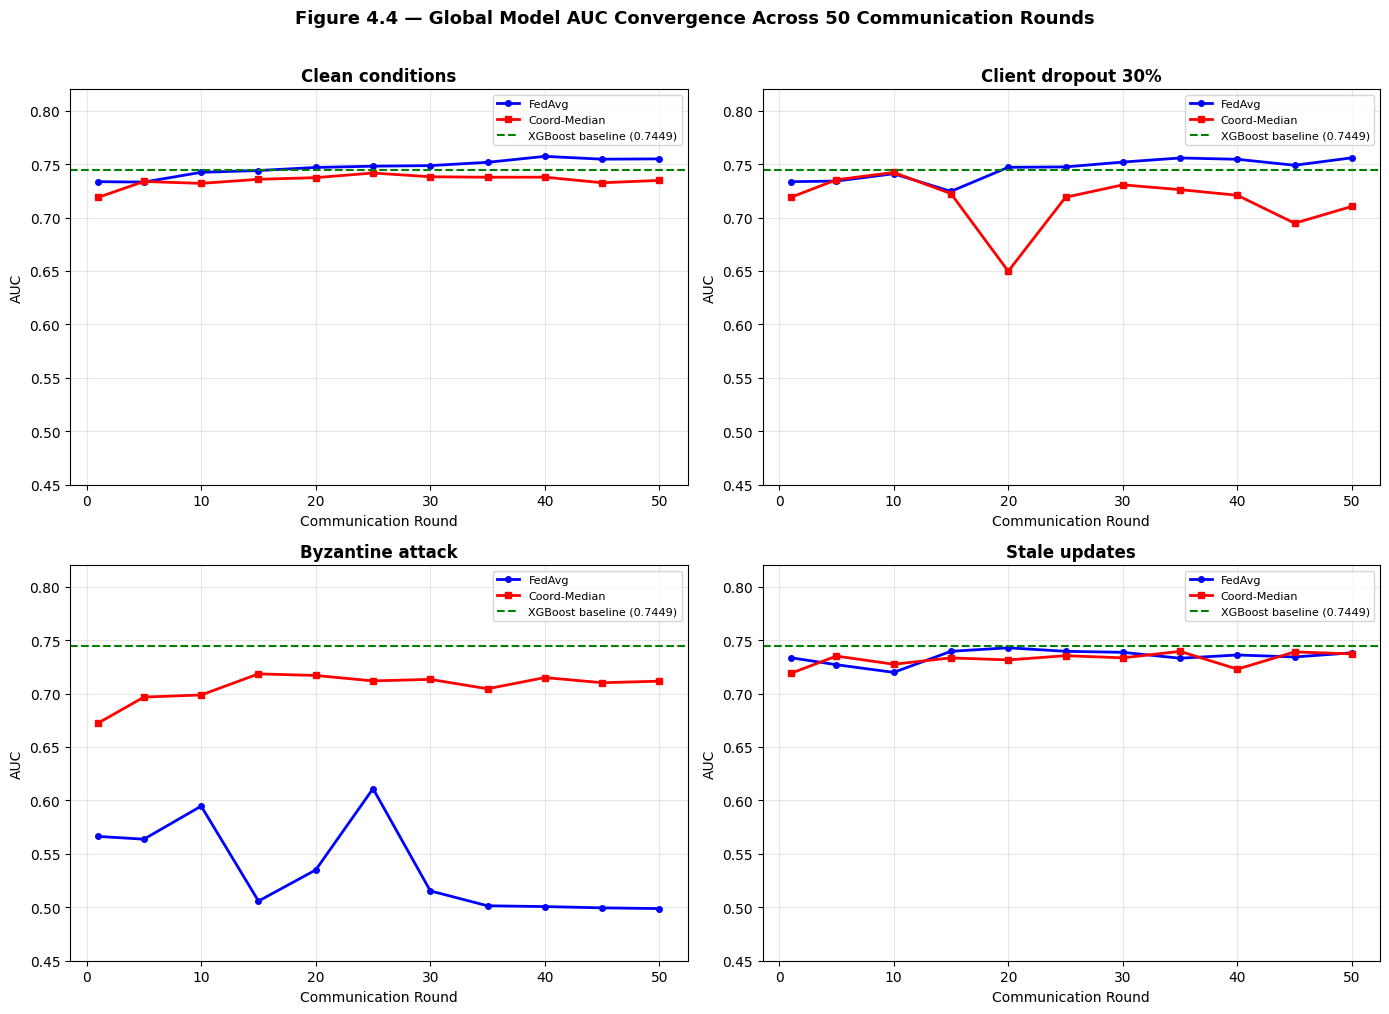

Saved: fig4_4_convergence_curves.png


In [2]:
# Displaying the convergence curves

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

groups = [
    ("Clean conditions",    "fedavg_clean",          "median_clean"),
    ("Client dropout 30%",  "fedavg_dropout",         "median_dropout"),
    ("Byzantine attack",    "fedavg_byzantine_fixed", "median_byzantine_fixed"),
    ("Stale updates",       "fedavg_stale",           "median_stale"),
]

for ax, (title, fedavg_key, median_key) in zip(axes, groups):
    # FedAvg
    fedavg_h = fl_histories[fedavg_key]
    rounds_f  = [h["round"] for h in fedavg_h]
    aucs_f    = [h["auc"]   for h in fedavg_h]
    ax.plot(rounds_f, aucs_f, "b-o", markersize=4,
            label="FedAvg", linewidth=2)

    # Median
    median_h = fl_histories[median_key]
    rounds_m  = [h["round"] for h in median_h]
    aucs_m    = [h["auc"]   for h in median_h]
    ax.plot(rounds_m, aucs_m, "r-s", markersize=4,
            label="Coord-Median", linewidth=2)

    # XGBoost baseline
    xgb_auc = baselines["XGBoost_centralised"]["auc"]
    ax.axhline(xgb_auc, color="green", linestyle="--",
               linewidth=1.5, label=f"XGBoost baseline ({xgb_auc:.4f})")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Communication Round")
    ax.set_ylabel("AUC")
    ax.set_ylim(0.45, 0.82)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Figure 4.4 — Global Model AUC Convergence Across 50 Communication Rounds",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/fig4_4_convergence_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_4_convergence_curves.png")

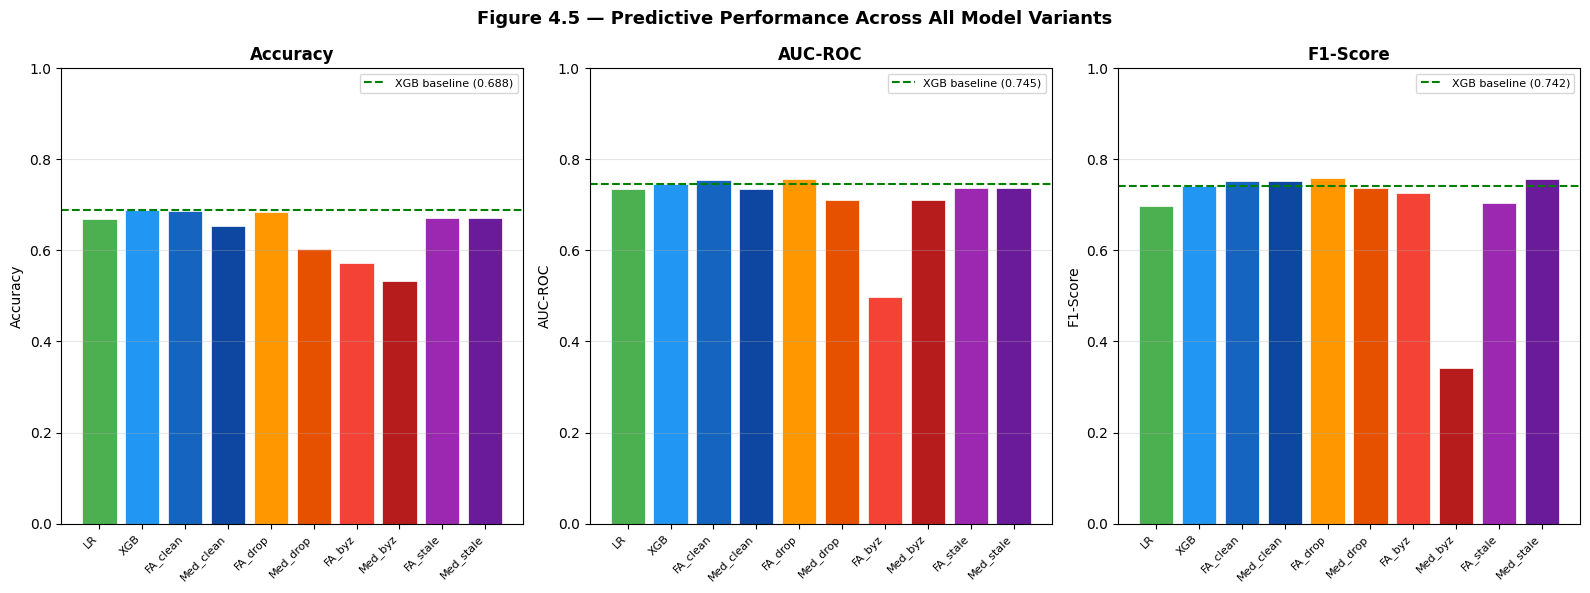

Saved: fig4_5_performance_comparison.png


In [3]:
# Performance comparison Charts

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics   = ["accuracy", "auc", "f1"]
titles    = ["Accuracy", "AUC-ROC", "F1-Score"]
xgb_vals  = [baselines["XGBoost_centralised"][m] for m in metrics]

labels = (
    ["LR_centralised", "XGBoost_centralised"] + VALID_EXPERIMENTS
)
short_labels = [
    "LR", "XGB",
    "FA_clean", "Med_clean",
    "FA_drop",  "Med_drop",
    "FA_byz",   "Med_byz",
    "FA_stale", "Med_stale",
]
colors = (
    ["#4CAF50", "#2196F3"] +
    ["#1565C0", "#0D47A1",
     "#FF9800", "#E65100",
     "#F44336", "#B71C1C",
     "#9C27B0", "#6A1B9A"]
)

all_vals = {}
for m in metrics:
    vals = []
    for label in labels:
        if label in baselines:
            vals.append(baselines[label][m])
        else:
            vals.append(fl_metrics[label][m])
    all_vals[m] = vals

for ax, metric, title, xgb_ref in zip(axes, metrics, titles, xgb_vals):
    bars = ax.bar(range(len(labels)), all_vals[metric],
                  color=colors, edgecolor="white", linewidth=0.5)
    ax.axhline(xgb_ref, color="green", linestyle="--",
               linewidth=1.5, label=f"XGB baseline ({xgb_ref:.3f})")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "Figure 4.5 — Predictive Performance Across All Model Variants",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/fig4_5_performance_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_5_performance_comparison.png")

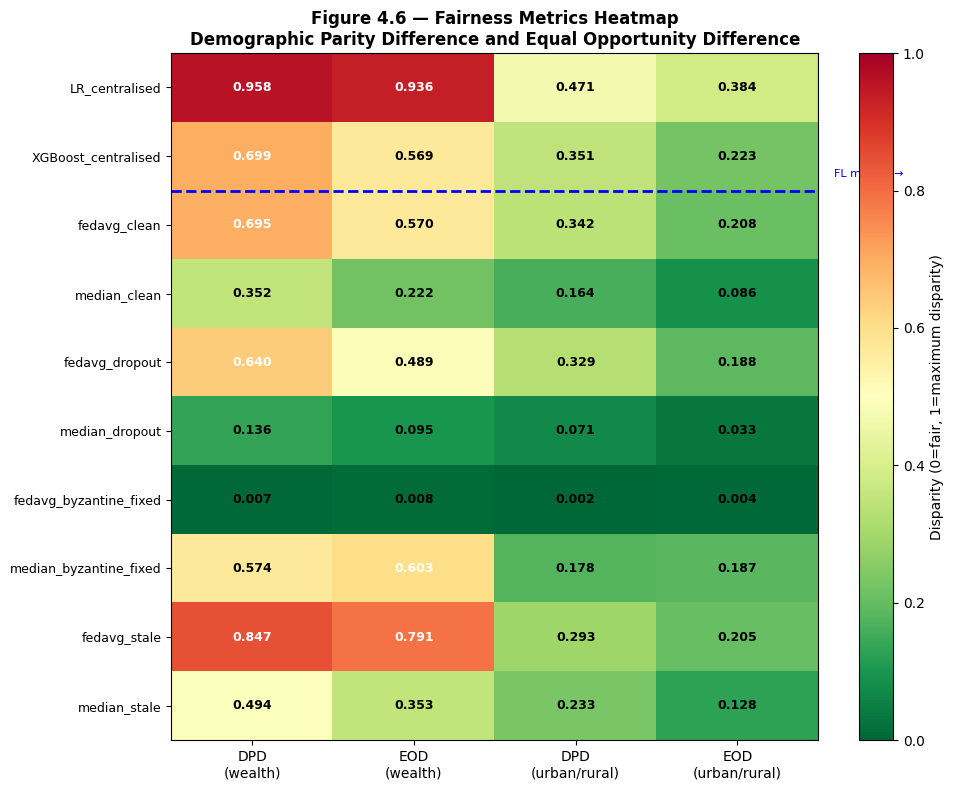

Saved: fig4_6_fairness_heatmap.png


In [4]:
# Illustrating the fairness heatmap

import matplotlib.colors as mcolors

fairness_plot_data = []
row_labels = []

for label, pred_dict in [
    ("LR_centralised",      {"DPD_wealth": 0.9583, "EOD_wealth": 0.9362,
                             "DPD_urban": 0.4713,  "EOD_urban": 0.3843}),
    ("XGBoost_centralised", {"DPD_wealth": 0.6985, "EOD_wealth": 0.5690,
                             "DPD_urban": 0.3507,  "EOD_urban": 0.2227}),
]:
    fairness_plot_data.append([
        pred_dict["DPD_wealth"], pred_dict["EOD_wealth"],
        pred_dict["DPD_urban"],  pred_dict["EOD_urban"]
    ])
    row_labels.append(label)

for _, row in fairness_df.iterrows():
    fairness_plot_data.append([
        row["DPD_wealth"], row["EOD_wealth"],
        row["DPD_urban"],  row["EOD_urban"]
    ])
    row_labels.append(row["experiment"])

data_array   = np.array(fairness_plot_data)
col_labels   = ["DPD\n(wealth)", "EOD\n(wealth)",
                "DPD\n(urban/rural)", "EOD\n(urban/rural)"]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data_array, cmap="RdYlGn_r", aspect="auto",
               vmin=0, vmax=1.0)

plt.colorbar(im, ax=ax, label="Disparity (0=fair, 1=maximum disparity)")

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

# Annotate cells
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val  = data_array[i, j]
        color = "white" if val > 0.6 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Threshold line
ax.axhline(1.5, color="blue", linewidth=2, linestyle="--")
ax.text(3.6, 1.3, "FL models →", color="blue", fontsize=8)

ax.set_title(
    "Figure 4.6 — Fairness Metrics Heatmap\n"
    "Demographic Parity Difference and Equal Opportunity Difference",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/fig4_6_fairness_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_6_fairness_heatmap.png")

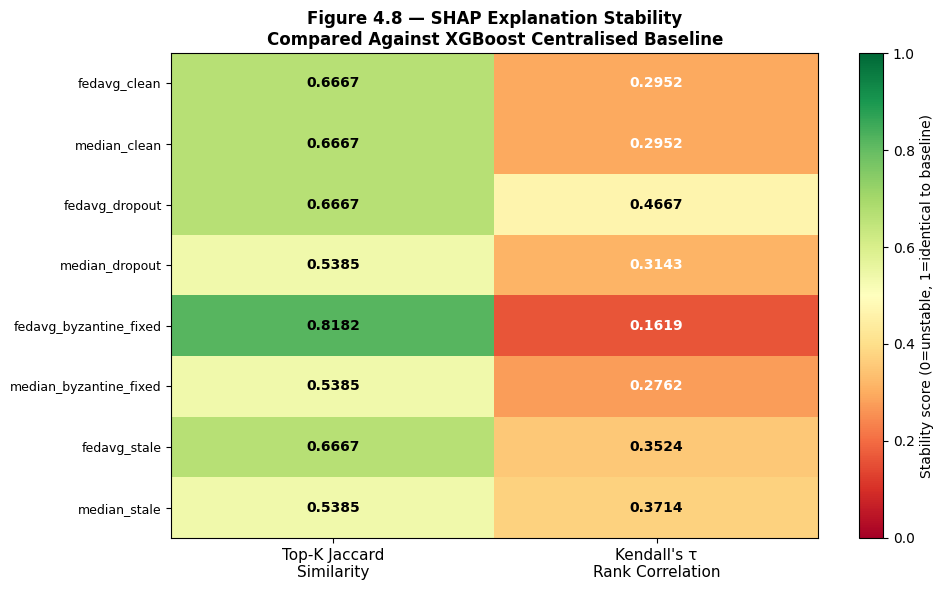

Saved: fig4_8_shap_stability_heatmap.png


In [5]:
# Plotting the SHAP stability heatmap

fig, ax = plt.subplots(figsize=(10, 6))

stab_data  = stability_df[["jaccard", "kendall_tau"]].values
row_labels = stability_df["experiment"].tolist()
col_labels = ["Top-K Jaccard\nSimilarity", "Kendall's τ\nRank Correlation"]

im = ax.imshow(stab_data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1.0)
plt.colorbar(im, ax=ax, label="Stability score (0=unstable, 1=identical to baseline)")

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=11)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val   = stab_data[i, j]
        color = "white" if val < 0.35 else "black"
        ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                fontsize=10, color=color, fontweight="bold")

ax.set_title(
    "Figure 4.8 — SHAP Explanation Stability\n"
    "Compared Against XGBoost Centralised Baseline",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/fig4_8_shap_stability_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_8_shap_stability_heatmap.png")

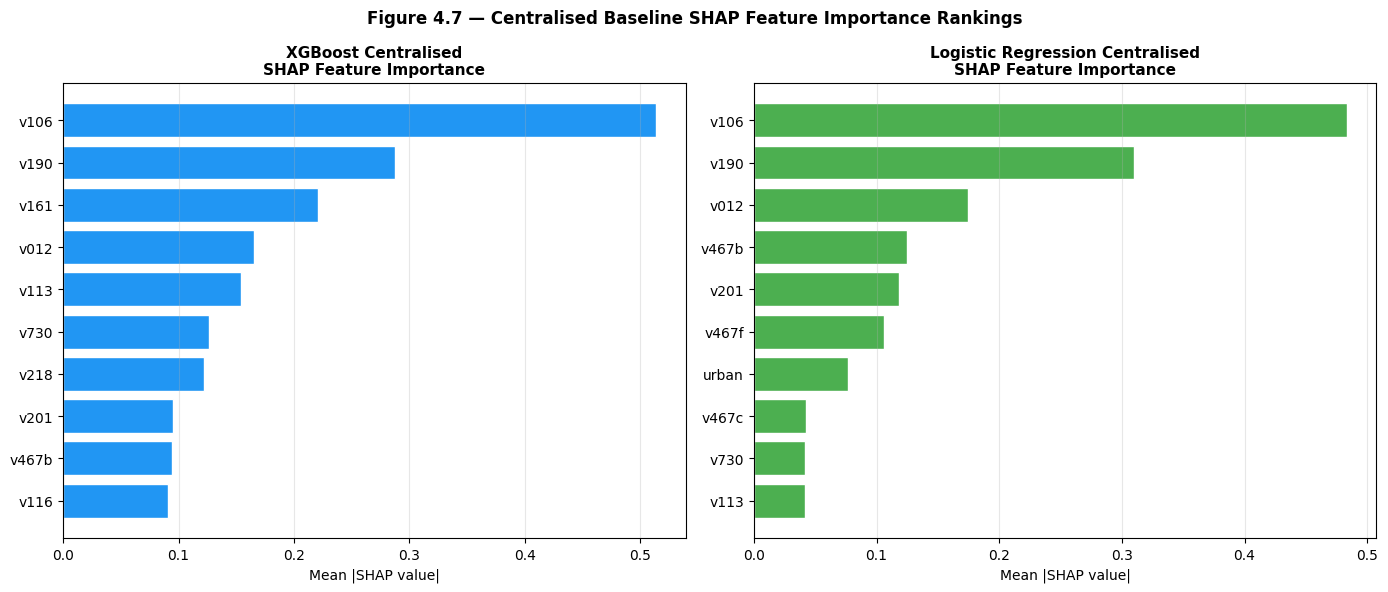

Saved: fig4_7_shap_comparison.png


In [6]:
# Side-by-side comparison of the top-10 most important features
# according to SHAP values for XGBoost and Logistic Regression

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost SHAP
top_xgb = shap_xgb.head(10)
axes[0].barh(top_xgb["feature"][::-1],
             top_xgb["mean_abs_shap"][::-1],
             color="#2196F3", edgecolor="white")
axes[0].set_title("XGBoost Centralised\nSHAP Feature Importance",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].grid(True, alpha=0.3, axis="x")

# LR SHAP
top_lr = shap_lr.head(10)
axes[1].barh(top_lr["feature"][::-1],
             top_lr["mean_abs_shap"][::-1],
             color="#4CAF50", edgecolor="white")
axes[1].set_title("Logistic Regression Centralised\nSHAP Feature Importance",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Mean |SHAP value|")
axes[1].grid(True, alpha=0.3, axis="x")

plt.suptitle(
    "Figure 4.7 — Centralised Baseline SHAP Feature Importance Rankings",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/fig4_7_shap_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_7_shap_comparison.png")

In [7]:
# Saving the visualisations

print("All figures saved:")
for fname in sorted(os.listdir("/kaggle/working/figures")):
    fpath = os.path.join("/kaggle/working/figures", fname)
    print(f"  {fname:<45} {os.path.getsize(fpath)/1e6:.2f} MB")

All figures saved:
  fig4_4_convergence_curves.png                 0.16 MB
  fig4_5_performance_comparison.png             0.08 MB
  fig4_6_fairness_heatmap.png                   0.14 MB
  fig4_7_shap_comparison.png                    0.07 MB
  fig4_8_shap_stability_heatmap.png             0.11 MB
